In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bar
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime

from TtoGmodel_15 import TextToGraphTransformer

In [2]:
from Circuits import Circuits
circuits= Circuits()

Loading dataset files...
Loaded dataset files successfully.


In [3]:
print(circuits.component_lists[0])
print(circuits.graphs[0])

['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [ ]:
import pickle

# Path to your .pkl file
pkl_file = 'component_prediction.pkl'

# Load the list of input sequences
with open(pkl_file, 'rb') as f:
    input_sequences = pickle.load(f)

# Example: print how many sequences and the first one
print(f"Loaded {len(input_sequences)} input sequences.")
print("First input sequence:", input_sequences[0])




Loaded 100 input sequences.
First input sequence: ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VOUT2', 'VB1', 'VB2', 'VB3', 'VB4', 'VREF1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G', 'NM3_S', 'NM3_B', 'NM4', 'NM4_D', 'NM4_G', 'NM4_S', 'NM4_B', 'NM5', 'NM5_D', 'NM5_G', 'NM5_S', 'NM5_B', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4']


In [4]:
def collate_fn(batch):
    seqs, mats = zip(*batch)

    # Convert sequences to torch tensors
    seqs = [torch.tensor(seq, dtype=torch.long) for seq in seqs]

    # Convert adjacency matrices (NumPy -> PyTorch)
    mats = [torch.tensor(mat, dtype=torch.float32) for mat in mats]

    # Get max sizes
    max_seq_len = max(len(seq) for seq in seqs)
    max_nodes = max(mat.size(0) for mat in mats)

    # Pad sequences
    padded_seqs = torch.stack([
        F.pad(seq, (0, max_seq_len - len(seq)), value=0)
        for seq in seqs
    ])

    # Pad adjacency matrices
    padded_mats = torch.stack([
        F.pad(mat, (0, max_nodes - mat.size(1), 0, max_nodes - mat.size(0)), value=0)
        for mat in mats
    ])

    seq_lengths = torch.tensor([len(seq) for seq in seqs])

    return padded_seqs, padded_mats, seq_lengths


In [5]:
#dataset = list(zip(circuits.component_indices, circuits.graphs))
#loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

from sklearn.model_selection import train_test_split
import torch

# Assuming 'dataset' is already created as:
dataset = list(zip(circuits.component_indices, circuits.graphs))

# 80% Train, 20% Test split
train_data, test_data = train_test_split(dataset, test_size=0.1, random_state=42)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,  # typically don't shuffle test data
    collate_fn=collate_fn
)


In [6]:
print("Test data size:", len(test_data))
#print("Test data example:", test_data[0])

# Convert test_data[0][0] to a tensor to access its shape
component_indices = torch.tensor(test_data[1][0])
adjacency_matrix = torch.tensor(test_data[1][1])

print("Test data shape (component indices):", component_indices.shape)
print("Test data shape (adjacency matrix):", adjacency_matrix.shape)

Test data size: 335
Test data shape (component indices): torch.Size([149])
Test data shape (adjacency matrix): torch.Size([149, 149])


In [7]:
# Get the first batch of data from train_loader
first_batch = next(iter(train_loader))

# Unpack the batch
input_seqs, adj_mats, seq_lengths = first_batch

# Print the first batch details
#print("Input Sequences:", input_seqs)
#print("Adjacency Matrices:", adj_mats)
print("Sequence Lengths:", seq_lengths)
print("Input Sequences Shape:", input_seqs.shape)
print("Adjacency Matrices Shape:", adj_mats.shape)
print("Input Sequences Lengths:", [len(seq) for seq in input_seqs])
print("Adjacency Matrices Lengths:", [mat.shape for mat in adj_mats])



Sequence Lengths: tensor([115,  79, 149, 187, 102,  89, 216,  84,  30,  25,  18, 113,  96, 109,
        138,  21, 104, 173, 184, 177, 135,  88,  98,  32,  34, 174, 102,  92,
         84, 150, 102, 103])
Input Sequences Shape: torch.Size([32, 216])
Adjacency Matrices Shape: torch.Size([32, 216, 216])
Input Sequences Lengths: [216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216, 216]
Adjacency Matrices Lengths: [torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torch.Size([216, 216]), torc

In [8]:
#Da
print(circuits.component_indices[0])
print(circuits.graphs[0])


[99, 601, 553, 194, 186, 497, 570, 228]
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [9]:
# Initialize model parameters
vocab_size = len(circuits.vocab)  # Number of unique components
embedding_dim = 128
hidden_dim = 256
num_heads = 8
num_layers = 4
dropout = 0.1

# Initialize the model
model = TextToGraphTransformer(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

TextToGraphTransformer(
  (embedding): Embedding(892, 128, padding_idx=0)
  (positional_encoding): SinusoidalPositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): R

/tmp/ipykernel_169200/139300081.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 [Training]:   0%|          | 0/95 [00:00<?, ?it/s]/tmp/ipykernel_169200/139300081.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_169200/139300081.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1] 🛠️ Train Loss: 0.5020
[Epoch 1] 🔍 Test Loss: 0.4729


[Epoch 2] 🛠️ Train Loss: 0.4468
[Epoch 2] 🔍 Test Loss: 0.4466


[Epoch 3] 🛠️ Train Loss: 0.4309
[Epoch 3] 🔍 Test Loss: 0.4281


[Epoch 4] 🛠️ Train Loss: 0.4000
[Epoch 4] 🔍 Test Loss: 0.3915


...

[Epoch 116] 🛠️ Train Loss: 0.0453
[Epoch 116] 🔍 Test Loss: 0.0532


[Epoch 117] 🛠️ Train Loss: 0.0457
[Epoch 117] 🔍 Test Loss: 0.0528


[Epoch 118] 🛠️ Train Loss: 0.0443
[Epoch 118] 🔍 Test Loss: 0.0534
⚠️ No improvement for 1 epochs.


[Epoch 119] 🛠️ Train Loss: 0.0442
[Epoch 119] 🔍 Test Loss: 0.0529
⚠️ No improvement for 2 epochs.


[Epoch 120] 🛠️ Train Loss: 0.0437
[Epoch 120] 🔍 Test Loss: 0.0529
⚠️ No improvement for 3 epochs.
💾 Checkpoint saved at epoch 120 → Saves/TtoGmodel_epoch120_20250503_200022.pth


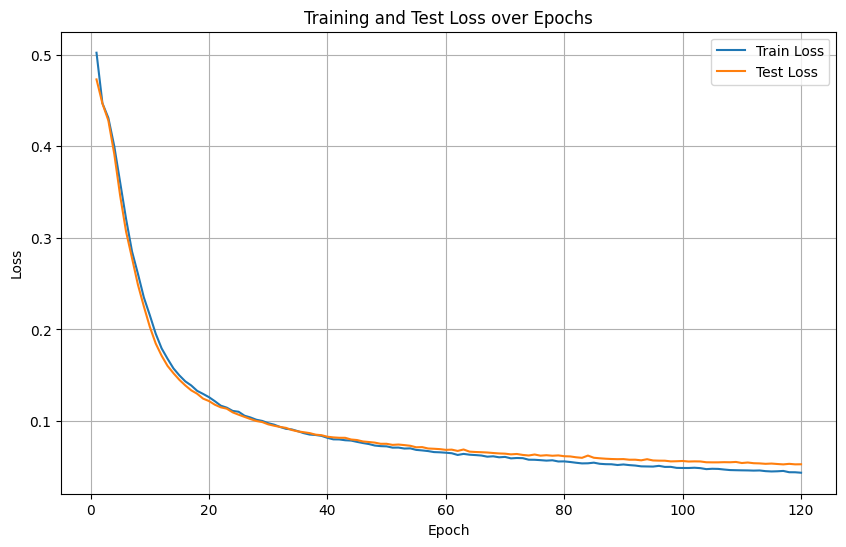

In [10]:
#Training Loop with dynamic pos_weight
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler
from datetime import datetime

PAD_TOKEN_ID = 0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()

num_epochs = 120
save_every = 10
early_stop_patience = 5  # Stop after 5 epochs of no improvement

train_losses = []
test_losses = []

best_test_loss = float('inf')
epochs_no_improve = 0
scalar = 0.05  # Adjust this value as needed

for epoch in range(1, num_epochs + 1):
    # ========== Training ==========    
    model.train()
    total_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        # Calculate pos_weight dynamically based on sequence length
        seq_length = seq_lengths.float().mean().item()  
        #pos_weight_value = (seq_length - 3) / 3  # Formula: pos_weight = (len - 3) / 3
        #pos_weight_value = max(pos_weight_value, 0.1)  # Ensure pos_weight doesn't go below 0.1
        #pos_weight = torch.tensor([pos_weight_value]).to(device)
        #print(f"Dynamic pos_weight: {pos_weight_value}")

        # Calculate the average number of zeros and ones in adj_mats
        num_elements = adj_mats.numel()
        num_ones = adj_mats.sum().item()
        num_zeros = num_elements - num_ones

        # Calculate pos_weight as the ratio of zeros to ones
        pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
        pos_weight_value = max(scalar*pos_weight_value, 1)
        pos_weight = torch.tensor([pos_weight_value]).to(device)



        # Define criterion with the dynamic pos_weight
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        optimizer.zero_grad()

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.detach().item()
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"[Epoch {epoch}] 🛠️ Train Loss: {avg_train_loss:.4f}")

    # ========== Evaluation ==========    
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device, non_blocking=True)
            adj_mats = adj_mats.to(device, non_blocking=True)
            seq_lengths = seq_lengths.to(device, non_blocking=True)

            # Calculate pos_weight dynamically based on sequence length
            seq_length = seq_lengths.float().mean().item() 
            #pos_weight_value = (seq_length - 3) / 3  # Formula: pos_weight = (len - 3) / 3
            #pos_weight_value = max(pos_weight_value, 0.1)  # Ensure pos_weight doesn't go below 0.1
            #pos_weight = torch.tensor([pos_weight_value]).to(device)

            # Calculate the average number of zeros and ones in adj_mats
            num_elements = adj_mats.numel()
            num_ones = adj_mats.sum().item()
            num_zeros = num_elements - num_ones

            # Calculate pos_weight as the ratio of zeros to ones
            pos_weight_value = num_zeros / max(num_ones, 1)  # Avoid division by zero
            pos_weight_value = max(scalar*pos_weight_value, 0.1)
            pos_weight = torch.tensor([pos_weight_value]).to(device)



            # Define criterion with the dynamic pos_weight
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            with autocast():
                seq_mask = (input_seqs != PAD_TOKEN_ID)
                predicted_logits = model(input_seqs, seq_mask)

                mask = (input_seqs != PAD_TOKEN_ID)
                mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
                mask_flat = mask2d.view(-1)
                pred_flat = predicted_logits.view(-1)
                true_flat = adj_mats.view(-1)

                loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

            total_test_loss += loss.detach().item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    print(f"[Epoch {epoch}] 🔍 Test Loss: {avg_test_loss:.4f}")

    # ========== Early Stopping Check ==========    
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epochs.")
        if epochs_no_improve >= early_stop_patience:
            print(f"⛔ Early stopping triggered at epoch {epoch}!")
            break

    # ========== Save Checkpoint ==========    
    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"Saves/TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save final model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')

# ========== Plotting Loss ==========    
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(test_losses)+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


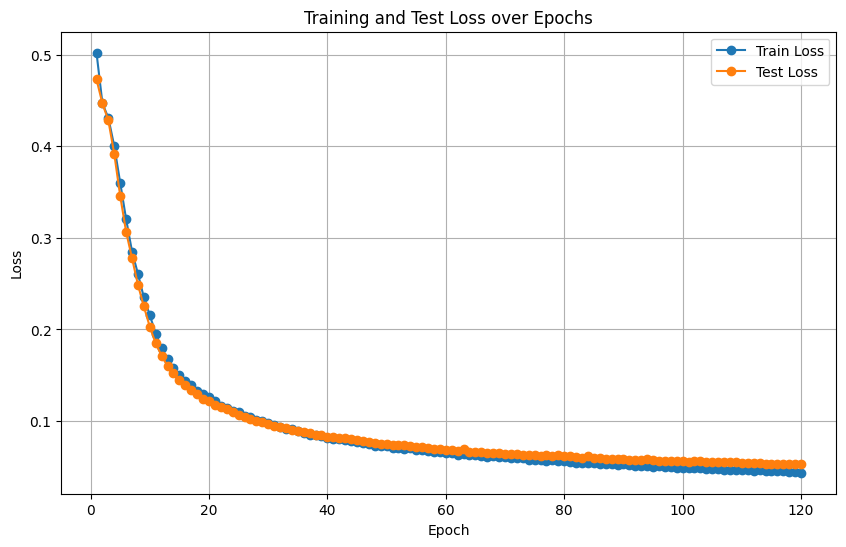

In [11]:
#Plotting Loss
import matplotlib.pyplot as plt
# ========== Plotting Loss ==========    
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss',marker='o')
plt.plot(range(1, len(test_losses)+1), test_losses, label='Test Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#Final Evaluation
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from torch.cuda.amp import autocast

PAD_TOKEN_ID = 0

output_file = "output.txt"

model.eval()
#scalar = 0.1
threshold = 0.5

# Separate lists for each metric
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
confusion_matrices = []

with open(output_file, "w") as f:
    f.write("Per-sample Evaluation Metrics\n")
    f.write("=" * 40 + "\n")

    sample_idx = 1
    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device)
            adj_mats = adj_mats.to(device)

            seq_mask = (input_seqs != PAD_TOKEN_ID)
            with autocast():
                predicted_logits = model(input_seqs, seq_mask)

            

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)

            pred_flat = torch.sigmoid(predicted_logits[mask2d]).cpu().numpy()
            true_flat = adj_mats[mask2d].cpu().numpy()

            # Binarize predictions with threshold 0.5
            pred_bin = (pred_flat >= threshold).astype(int)

            try:
                cm = confusion_matrix(true_flat, pred_bin, labels=[0, 1])
                precision = precision_score(true_flat, pred_bin, zero_division=0)
                recall = recall_score(true_flat, pred_bin, zero_division=0)
                f1 = f1_score(true_flat, pred_bin, zero_division=0)
                acc = accuracy_score(true_flat, pred_bin)
            except ValueError:
                f.write(f"[Sample {sample_idx}] Skipped due to metric error.\n")
                sample_idx += 1
                continue

            # Save metrics in lists
            precision_list.append(precision)
            recall_list.append(recall)
            f1_list.append(f1)
            accuracy_list.append(acc)
            confusion_matrices.append(cm)

            # Log to file
            f.write(f"[Sample {sample_idx}]\n")
            f.write(f"Confusion Matrix:\n{cm}\n")
            f.write(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, Accuracy: {acc:.4f}\n")
            f.write("-" * 40 + "\n")

            sample_idx += 1

    # Compute and log average metrics
    avg_precision = sum(precision_list) / len(precision_list)
    avg_recall = sum(recall_list) / len(recall_list)
    avg_f1 = sum(f1_list) / len(f1_list)
    avg_accuracy = sum(accuracy_list) / len(accuracy_list)

    f.write("\nAverage Evaluation Metrics\n")
    f.write("=" * 40 + "\n")
    f.write(f"Average Precision: {avg_precision:.4f}\n")
    f.write(f"Average Recall: {avg_recall:.4f}\n")
    f.write(f"Average F1 Score: {avg_f1:.4f}\n")
    f.write(f"Average Accuracy: {avg_accuracy:.4f}\n")

/tmp/ipykernel_169200/1256611793.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_169200/1256611793.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_169200/1256611793.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_169200/1256611793.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_169200/1256611793.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_169200/1256611793.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` 

/tmp/ipykernel_167967/3645781536.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_167967/3645781536.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_167967/3645781536.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_167967/3645781536.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_167967/3645781536.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_167967/3645781536.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` 

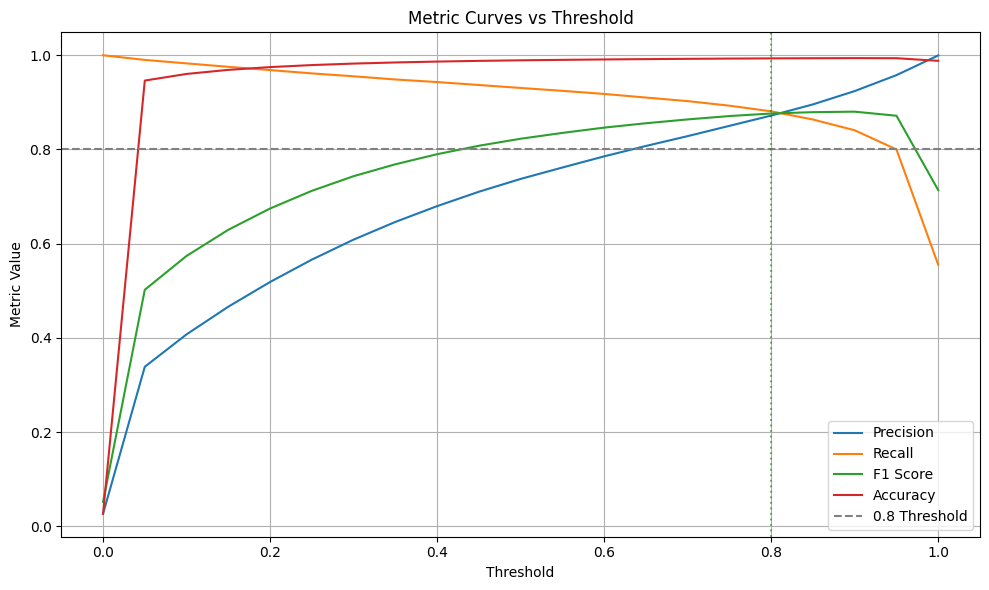

In [ ]:
#Final Evalutaion to determine best threshold
import torch
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from torch.cuda.amp import autocast
import numpy as np
import matplotlib.pyplot as plt

PAD_TOKEN_ID = 0
output_file = "output.txt"
model.eval()

best_threshold = 0
best_score_sum = -1
best_metrics = {}

threshold_range = np.arange(0.0, 1.05, 0.05)

# For plotting
precision_curve = []
recall_curve = []
f1_curve = []
accuracy_curve = []

valid_thresholds = []

for threshold in threshold_range:
    precision_list = []
    recall_list = []
    f1_list = []
    accuracy_list = []
    
    sample_idx = 1
    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device)
            adj_mats = adj_mats.to(device)
            seq_mask = (input_seqs != PAD_TOKEN_ID)

            with autocast():
                predicted_logits = model(input_seqs, seq_mask)

            predicted_probs = torch.sigmoid(predicted_logits)
            predicted_probs = (predicted_probs + predicted_probs.transpose(1, 2)) / 2

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)

            pred_flat = predicted_probs[mask2d].cpu().numpy()
            true_flat = adj_mats[mask2d].cpu().numpy()

            pred_bin = (pred_flat >= threshold).astype(int)

            try:
                precision = precision_score(true_flat, pred_bin, zero_division=0)
                recall = recall_score(true_flat, pred_bin, zero_division=0)
                f1 = f1_score(true_flat, pred_bin, zero_division=0)
                acc = accuracy_score(true_flat, pred_bin)
            except ValueError:
                continue

            precision_list.append(precision)
            recall_list.append(recall)
            f1_list.append(f1)
            accuracy_list.append(acc)
            sample_idx += 1

    if len(precision_list) == 0:
        # Fill with NaNs to maintain plot index alignment
        precision_curve.append(np.nan)
        recall_curve.append(np.nan)
        f1_curve.append(np.nan)
        accuracy_curve.append(np.nan)
        continue

    avg_precision = sum(precision_list) / len(precision_list)
    avg_recall = sum(recall_list) / len(recall_list)
    avg_f1 = sum(f1_list) / len(f1_list)
    avg_accuracy = sum(accuracy_list) / len(accuracy_list)

    # Store for plotting
    precision_curve.append(avg_precision)
    recall_curve.append(avg_recall)
    f1_curve.append(avg_f1)
    accuracy_curve.append(avg_accuracy)

    # Check if all metrics > 0.8
    if all(metric >= 0.87 for metric in [avg_precision, avg_recall, avg_f1, avg_accuracy]):
        valid_thresholds.append(threshold)

    score_sum = avg_precision + avg_recall + avg_f1 + avg_accuracy

    if score_sum > best_score_sum:
        best_score_sum = score_sum
        best_threshold = threshold
        best_metrics = {
            "precision": avg_precision,
            "recall": avg_recall,
            "f1": avg_f1,
            "accuracy": avg_accuracy
        }

# Save best result to file
with open(output_file, "w") as f:
    f.write("Best Threshold Optimization Result\n")
    f.write("=" * 40 + "\n")
    f.write(f"Best Threshold: {best_threshold:.2f}\n")
    f.write(f"Precision: {best_metrics['precision']:.4f}\n")
    f.write(f"Recall: {best_metrics['recall']:.4f}\n")
    f.write(f"F1 Score: {best_metrics['f1']:.4f}\n")
    f.write(f"Accuracy: {best_metrics['accuracy']:.4f}\n")
    f.write(f"Sum of Metrics: {best_score_sum:.4f}\n")
    if valid_thresholds:
        f.write("\nThresholds where all metrics > 0.8:\n")
        f.write(", ".join([f"{t:.2f}" for t in valid_thresholds]) + "\n")
    else:
        f.write("\nNo thresholds where all metrics > 0.8\n")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(threshold_range, precision_curve, label="Precision")
plt.plot(threshold_range, recall_curve, label="Recall")
plt.plot(threshold_range, f1_curve, label="F1 Score")
plt.plot(threshold_range, accuracy_curve, label="Accuracy")
plt.axhline(0.8, color='gray', linestyle='--', label='0.8 Threshold')

for vt in valid_thresholds:
    plt.axvline(vt, color='green', linestyle=':', alpha=0.5)

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Metric Curves vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
from tqdm import tqdm
import networkx as nx

In [39]:
#Final Evaluation
import torch
import torch.nn as nn
from torch.cuda.amp import autocast

PAD_TOKEN_ID = 0

output_file = "output.txt"

model.eval()
#scalar = 0.1
threshold = 0.5

# Separate lists for each metric
precision_list = []
recall_list = []
f1_list = []
accuracy_list = []
confusion_matrices = []

with open(output_file, "w") as f:
    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device)
            adj_mats = adj_mats.to(device)

            with autocast():
                seq_mask = (input_seqs != PAD_TOKEN_ID)
                predicted_logits = model(input_seqs, seq_mask)

                mask = (input_seqs != PAD_TOKEN_ID)
                mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
                mask_flat = mask2d.view(-1)
                #pred_flat = predicted_logits.view(-1)
                #true_flat = adj_mats.view(-1)
                
                # Convert the adjacency matrix to a NetworkX graph

            graph = nx.from_numpy_array()

            # Check if the graph is connected
            is_connected = nx.is_connected(graph)
            
            G = nx.Graph()

            # # Binarize predictions with threshold 0.5
            # pred_bin = (pred_flat >= threshold).astype(int)

            # print("Pred_bin shape:", pred_bin.shape)

            # cm = confusion_matrix(true_flat, pred_bin, labels=[0, 1])
            # precision = precision_score(true_flat, pred_bin, zero_division=0)
            # recall = recall_score(true_flat, pred_bin, zero_division=0)
            # f1 = f1_score(true_flat, pred_bin, zero_division=0)
            # acc = accuracy_score(true_flat, pred_bin)




/tmp/ipykernel_167967/2645836655.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


TypeError: from_numpy_array() missing 1 required positional argument: 'A'

In [ ]:
import torch
import torch.nn as nn
import networkx as nx
from torch.cuda.amp import autocast
from torch.nn.functional import sigmoid

PAD_TOKEN_ID = 0
threshold = 0.5  # For binarizing the predicted adjacency

model.eval()

connected_count = 0  # Counter for connected graphs
sample_count = 0  # Counter for total samples

with torch.no_grad():
    for i, (component_indices, adj_matrix) in enumerate(test_data):
        input_seqs = torch.tensor(component_indices).unsqueeze(0).to(device)  # shape: (1, N)
        adj_mats = torch.tensor(adj_matrix).unsqueeze(0).to(device)  # shape: (1, N, N)

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)  # shape: (1, N)
            predicted_logits = model(input_seqs, seq_mask)  # shape: (1, N, N)

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)  # shape: (1, N, N)

            predicted_probs = sigmoid(predicted_logits)  # shape: (1, N, N)
            masked_preds = predicted_probs * mask2d.float()

            adj_pred = masked_preds[0]  # shape: (N, N)
            adj_binary = (adj_pred >= threshold).float()
            adj_np = adj_binary.cpu().numpy()

            graph = nx.from_numpy_array(adj_np)
            is_connected = nx.is_connected(graph)

            if sample_count < 5:
                print(f"Sample {i} - Predicted Adjacency Matrix:\n{adj_np}")
                sample_count += 1

            if is_connected:
                connected_count += 1

            print(f"Sample {i} connected: {is_connected}")

print(f"\nTotal connected graphs: {connected_count} out of {len(test_data)}")


/tmp/ipykernel_169200/2085393970.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Sample 0 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
Sample 0 connected: True
Sample 1 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]]
Sample 1 connected: False
Sample 2 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
Sample 2 connected: True
Sample 3 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
Sample 3 connected: False
Sample 4 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...

Sample 44 connected: True
Sample 45 connected: True
Sample 46 connected: False
Sample 47 connected: True
Sample 48 connected: True
Sample 49 connected: True
Sample 50 connected: True
Sample 51 connected: True
Sample 52 connected: True
Sample 53 connected: True
Sample 54 connected: True
Sample 55 connected: True
Sample 56 connected: True
Sample 57 connected: True
Sample 58 connected: True
Sample 59 connected: False
Sample 60 connected: True
Sample 61 connected: True
Sample 62 connected: True
Sample 63 connected: True
Sample 64 connected: False
Sample 65 connected: True
Sample 66 connected: False
Sample 67 connected: True
Sample 68 connected: True
Sample 69 connected: False
Sample 70 connected: False
Sample 71 connected: True
Sample 72 connected: True
Sample 73 connected: True
Sample 74 connected: False
Sample 75 connected: True
Sample 76 connected: False
Sample 77 connected: True
Sample 78 connected: True
Sample 79 connected: True
Sample 80 connected: True
Sample 81 connected: True
Samp

: 

In [17]:
import torch
import torch.nn as nn
import networkx as nx
from torch.cuda.amp import autocast
from torch.nn.functional import sigmoid

PAD_TOKEN_ID = 0
threshold = 0.5  # For binarizing the predicted adjacency

model.eval()

connected_count = 0  # Counter for connected graphs
sample_count = 0  # Counter for total samples

with torch.no_grad():
    for i, (component_indices, adj_matrix) in enumerate(test_data):
        input_seqs = torch.tensor(component_indices).unsqueeze(0).to(device)  # shape: (1, N)
        adj_mats = torch.tensor(adj_matrix).unsqueeze(0).to(device)  # shape: (1, N, N)

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)  # shape: (1, N)
            predicted_logits = model(input_seqs, seq_mask)  # shape: (1, N, N)

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)  # shape: (1, N, N)

            predicted_probs = sigmoid(predicted_logits)  # shape: (1, N, N)
            masked_preds = predicted_probs * mask2d.float()

            adj_pred = masked_preds[0]  # shape: (N, N)

            # SYMMETRIZE: make the matrix symmetric
            adj_pred_sym = (adj_pred + adj_pred.T) / 2.0

            # BINARIZE
            adj_binary = (adj_pred_sym >= threshold).float()

            # # FIX ISOLATED NODES
            # for row_idx in range(adj_binary.size(0)):
            #     if adj_binary[row_idx].sum() == 0:
            #         # Find column with max probability in the symmetrized matrix
            #         max_idx = torch.argmax(adj_pred_sym[row_idx])
            #         adj_binary[row_idx, max_idx] = 1.0
            #         adj_binary[max_idx, row_idx] = 1.0  # Keep it symmetric

            adj_np = adj_binary.cpu().numpy()
            graph = nx.from_numpy_array(adj_np)
            is_connected = nx.is_connected(graph)

            if sample_count < 5:
                print(f"Sample {i} - Predicted Adjacency Matrix:\n{adj_np}")
                sample_count += 1

            if is_connected:
                connected_count += 1

            print(f"Sample {i} connected: {is_connected}")

print(f"\nTotal connected graphs: {connected_count} out of {len(test_data)}")


/tmp/ipykernel_169200/3703406157.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Sample 0 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
Sample 0 connected: True
Sample 1 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]]
Sample 1 connected: False
Sample 2 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
Sample 2 connected: True
Sample 3 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
Sample 3 connected: False
Sample 4 - Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...

In [ ]:
def predict_and_evaluate(predictor, data, device="cpu"):    
    input=data
    component_types =torch.tensor(input[0]).to(device)
    adjacency_matrix = torch.zeros((len(component_types),len(component_types))).to(device)
    model=predictor.model.to(device)
    tqdm_iter = tqdm(range(5), desc="Generating Adjacency Matrix")
    for _ in tqdm_iter:
        edge_preds = predict_edges(model, component_types, adjacency_matrix,device=device)
        adjacency_matrix = generate_edges_with_thrishold(edge_preds, component_types)
    adjacency_matrix = adjacency_matrix.cpu().numpy()
    predicted = torch.tensor(adjacency_matrix).to("cpu")
    # Convert the adjacency matrix to a NetworkX graph
    graph = nx.from_numpy_array(adjacency_matrix)

    # Check if the graph is connected
    is_connected = nx.is_connected(graph)
    
    G = nx.Graph()

    num_nodes = adjacency_matrix.shape[0]

    component_types =circuits.get_component_fromlist(component_types.tolist())
    
    # Add nodes with type info
    for i in range(num_nodes):
        G.add_node(i, type=component_types[i])

    # Add edges based on adjacency matrix
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):  # Avoid double-counting in undirected graph
            if adjacency_matrix[i, j] == 1:
                G.add_edge(i, j)

    floating_ports = False
    for node in G.nodes:
        if G.degree[node] < 1:
            floating_ports = True 

    vdd_nodes = [i for i, t in enumerate(component_types) if t.upper() == "VDD"]
    gnd_nodes = [i for i, t in enumerate(component_types) if t.upper() == "VSS"]

    if vdd_nodes  and gnd_nodes:
        power_ports = True
    else:
        power_ports = False

    # 3. Check for direct short between VDD and GND
    short_circuit = False
    for vdd in vdd_nodes:
        for gnd in gnd_nodes:
            if G.has_edge(vdd, gnd):
                short_circuit = True

    return {"input": input, "is_connected": True}  if power_ports and not short_circuit and is_connected and not floating_ports else {"input": input, "is_connected": False, "floating_ports": True}